# Testing
### Bevölkerungsszenarien 1993 - 2024 – 2050

Datum: 08.07.2025


**Dataset auf INTEG Datenkatalog**: https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_szenarien_od3440

**Dataset auf PROD Datenkatalog**: https://data.stadt-zuerich.ch/dataset/bev_szenarien_od3440

*Beschreibung*
Der Datensatz enthält Bevölkerungsszenarien zur zukünftigen Entwicklung der Wohnbevölkerung der Stadt Zürich. Es wird unterschieden nach drei Szenarien, wobei das mittlere Szenario die wahrscheinlichste Entwicklung abbildet. Der Datensatz enthält die Wohnbevölkerung der Stadt Zürich nach Szenario, Jahr, Alterklasse, Geschlecht, Herkunft sowie nach Stadtquartier. Der vorhandene Datensatz wird jährlich mit den neuen Szenariendaten aktualisiert.

### Importiere die notwendigen Packages

In [2]:
#%pip install geopandas altair fiona requests folium mplleaflet contextily seaborn datetime plotly leafmap

In [3]:
import altair as alt
import datetime
import folium 
import geopandas as gpd
import io
from IPython.display import Markdown as md
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#import pivottablejs
#from pivottablejs import pivot_ui
import plotly.express as px
import requests
import seaborn as sns

Importiere die eigenen Funktionen, die unter ../0_scripts abegelegt sind:

In [4]:
import sys
sys.path.append('../0_scripts')

import my_py_dataviz_functions as mypy_dv
import my_py_dataloading_functions as mypy_dl

In [5]:
SSL_VERIFY = False
# evtl. SSL_VERIFY auf False setzen wenn die Verbindung zu https://www.gemeinderat-zuerich.ch nicht klappt (z.B. wegen Proxy)
# Um die SSL Verifikation auszustellen, bitte die nächste Zeile einkommentieren ("#" entfernen)
# SSL_VERIFY = False

In [6]:
if not SSL_VERIFY:
    import urllib3
    urllib3.disable_warnings()

### Settings
Definiere Settings. 
Hier das Zahlenformat von Float-Werten (z.B. *'{:,.2f}'.format* mit Komma als Tausenderzeichen)

In [7]:
#pd.options.display.float_format = lambda x : '{:,.1f}'.format(x) if (np.isnan(x) | np.isinf(x)) else '{:,.0f}'.format(x) if int(x) == x else '{:,.1f}'.format(x)
pd.options.display.float_format = '{:.0f}'.format
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 15)

#### Zeitvariabeln


In [8]:
#Zeitvariabeln als Strings:
now = datetime.date.today()
year_today = now.strftime("%Y")
date_today = "_"+now.strftime("%Y-%m-%d")

#Zeitvariabeln als Integers:
int_times = now.timetuple()
aktuellesJahr = int_times[0]
aktuellerMonat = int_times[1]
selectedMonat = int_times[1]-2
#print(aktuellesJahr, aktuellerMonat,'datenstand: ', selectedMonat, int_times)

### Daten importieren und Metadaten checken

- status: int / prod
- data_source: web / ld / dropzone
- datums_attr: beschreibt das oder die Datumsfelder, die als Datum geparsed werden sollen. Falls es keines gibt: None

In [9]:
package_name = "bev_szenarien_od3440"

In [10]:
data2betested = mypy_dl.load_data(
    status = 'prod'
    , data_source = 'web'
    , package_name = package_name
    , dataset_name = "BEV344OD3440"    
    , datums_attr = ['StichtagDatJahr']
    )

fp lautet:https://data.stadt-zuerich.ch/dataset/bev_szenarien_od3440/download/BEV344OD3440.csv


 **Überprüfe die Metadaten:**

 **Dataset auf PROD-Datakatalog:** Link https://data.stadt-zuerich.ch/dataset/bev_szenarien_od3440 

 **Dataset auf INTEG-Datakatalog:** Link https://data.integ.stadt-zuerich.ch/dataset/bev_szenarien_od3440 

data_source: web


In [11]:
data2betested.head(2).T

,0,1
VersionArtSort,1,1
VersionArtLang,unteres Szenario,unteres Szenario
StichtagDatJahr,1993-01-01 00:00:00,1993-01-01 00:00:00
BasisSzenarienSort,1,1
BasisSzenarienLang,Vergangenheit,Vergangenheit
AlterV10Sort,1,1
AlterV10Lang,0- bis 9-Jährige,0- bis 9-Jährige
SexSort,1,1
SexLang,männlich,männlich
HerkunftSort,1,1


Berechne weitere Attribute falls notwendig

In [12]:
data2betested = (
    data2betested
    .copy()
    .assign(
        #Aktualisierungs_Datum_str= lambda x: x.Aktualisierungs_Datum.astype(str),
        StichtagDatJahr_str = lambda x: x.StichtagDatJahr.astype(str),
        Jahr = lambda x: x.StichtagDatJahr,
        Jahr_nbr = lambda x: x.Jahr.dt.year,
    )
    .sort_values('StichtagDatJahr', ascending=False)
    )
data2betested.dtypes

VersionArtSort                  int64
VersionArtLang                 object
StichtagDatJahr        datetime64[ns]
BasisSzenarienSort              int64
BasisSzenarienLang             object
AlterV10Sort                    int64
AlterV10Lang                   object
SexSort                         int64
SexLang                        object
HerkunftSort                    int64
HerkunftLang                   object
QuarSort                        int64
QuarLang                       object
AnzBestWir                      int64
StichtagDatJahr_str            object
Jahr                   datetime64[ns]
Jahr_nbr                        int32
dtype: object

Minimales und maximales Jahr im Datensatz

In [13]:
data_max_date = str(max(data2betested.Jahr).year)
data_min_date = str(min(data2betested.Jahr).year)

print(f"Die Daten haben ein Minimumjahr von {data_min_date} und ein Maximumjahr von {data_max_date}")

Die Daten haben ein Minimumjahr von 1993 und ein Maximumjahr von 2050


### Einfache Datentests

In [14]:
data2betested.info(memory_usage='deep', verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 228609 entries, 228608 to 0
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   VersionArtSort       228609 non-null  int64         
 1   VersionArtLang       228609 non-null  object        
 2   StichtagDatJahr      228609 non-null  datetime64[ns]
 3   BasisSzenarienSort   228609 non-null  int64         
 4   BasisSzenarienLang   228609 non-null  object        
 5   AlterV10Sort         228609 non-null  int64         
 6   AlterV10Lang         228609 non-null  object        
 7   SexSort              228609 non-null  int64         
 8   SexLang              228609 non-null  object        
 9   HerkunftSort         228609 non-null  int64         
 10  HerkunftLang         228609 non-null  object        
 11  QuarSort             228609 non-null  int64         
 12  QuarLang             228609 non-null  object        
 13  AnzBestWir         

In [15]:
print(f'The dataset has {data2betested.shape[0]:,.0f} rows (observations) and {data2betested.shape[1]:,.0f} columns (variables).')
print(f'There seem to be {data2betested.duplicated().sum()} exact duplicates in the data.')

The dataset has 228,609 rows (observations) and 17 columns (variables).
There seem to be 0 exact duplicates in the data.


Beschreibe einzelne Attribute

In [16]:
data2betested.describe()

,VersionArtSort,StichtagDatJahr,BasisSzenarienSort,AlterV10Sort,SexSort,HerkunftSort,QuarSort,AnzBestWir,Jahr,Jahr_nbr
count,228609,228609,228609,228609,228609,228609,228609,228609,228609,228609
mean,2,2022-01-14 03:23:42.510924288,1,6,2,1,70,336,2022-01-14 03:23:42.510924288,2022
min,1,1993-01-01 00:00:00,1,1,1,1,10,0,1993-01-01 00:00:00,1993
25%,1,2008-01-01 00:00:00,1,3,1,1,41,65,2008-01-01 00:00:00,2008
50%,2,2022-01-01 00:00:00,1,6,2,1,72,223,2022-01-01 00:00:00,2022
75%,3,2037-01-01 00:00:00,2,8,2,2,101,473,2037-01-01 00:00:00,2037
max,3,2050-01-01 00:00:00,2,11,2,2,123,3170,2050-01-01 00:00:00,2050
std,1,NaN,0,3,0,0,34,363,NaN,17


Welches sind die Quartiere ohne Werte bei BEW?

In [17]:
data2betested[np.isnan(data2betested.AnzBestWir)]

,VersionArtSort,VersionArtLang,StichtagDatJahr,BasisSzenarienSort,BasisSzenarienLang,AlterV10Sort,AlterV10Lang,...,HerkunftLang,QuarSort,QuarLang,AnzBestWir,StichtagDatJahr_str,Jahr,Jahr_nbr


### Verwende das Datum als Index

While we did already parse the `datetime` column into the respective datetime type, it currently is just a regular column. 
**To enable quick and convenient queries and aggregations, we need to turn it into the index of the DataFrame**

In [18]:
data2betested = data2betested.set_index("StichtagDatJahr")
data2betested = data2betested.sort_index()

In [19]:
data2betested.index.year.unique()

Index([1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007,
       2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022,
       2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035, 2036, 2037,
       2038, 2039, 2040, 2041, 2042, 2043, 2044, 2045, 2046, 2047, 2048, 2049, 2050],
      dtype='int32', name='StichtagDatJahr')

### Beschreibe einzelne Attribute

Beschreibe nicht numerische Attribute

In [20]:
# describe non-numerical features
try:
    with pd.option_context('display.float_format', '{:,.2f}'.format):
        display(data2betested.describe(exclude='number',datetime_is_numeric=True))
except:
    print("No categorical data in dataset.")

No categorical data in dataset.


Beschreibe numerische Attribute

In [21]:
# describe numerical features
try:
    with pd.option_context('display.float_format', '{:,.0f}'.format):
        display(data2betested.describe(include='number'))
except:
    print("No numercial data in dataset.")

,VersionArtSort,BasisSzenarienSort,AlterV10Sort,SexSort,HerkunftSort,QuarSort,AnzBestWir,Jahr_nbr
count,"228,609","228,609","228,609","228,609","228,609","228,609","228,609","228,609"
mean,2,1,6,2,1,70,336,"2,022"
std,1,0,3,0,0,34,363,17
min,1,1,1,1,1,10,0,"1,993"
25%,1,1,3,1,1,41,65,"2,008"
50%,2,1,6,2,1,72,223,"2,022"
75%,3,2,8,2,2,101,473,"2,037"
max,3,2,11,2,2,123,"3,170","2,050"


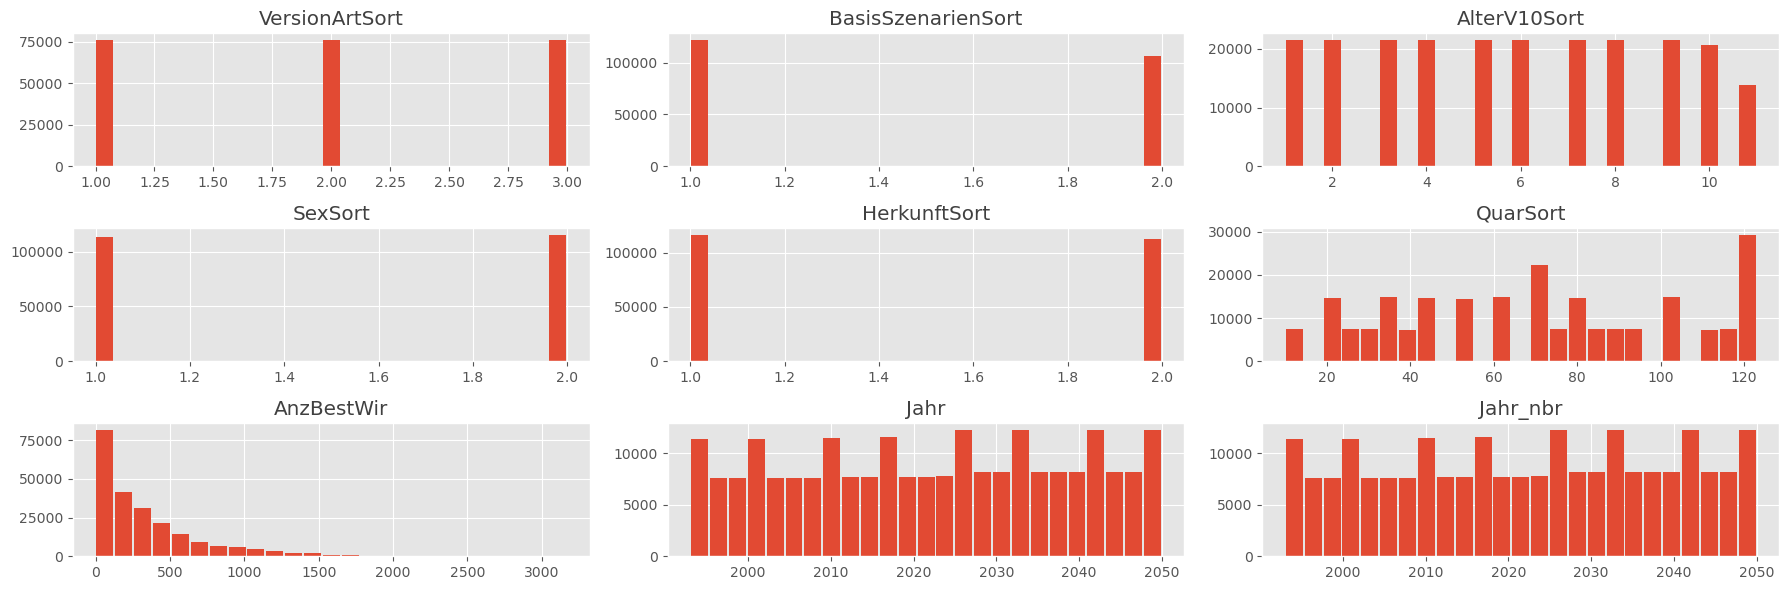

In [22]:
plt.style.use('ggplot')
params = {
    'text.color': (0.25, 0.25, 0.25),
    'figure.figsize': [18, 6],
   }
plt.rcParams.update(params)

try:
    data2betested.hist(bins=25, rwidth=0.9)
    plt.tight_layout()
    plt.show()
except:
    print("No numercial data to plot.") 

### Gibt es Duplikate?

In [23]:
# find duplicate rows
duplicate_rows = data2betested[data2betested.duplicated()]
duplicate_rows

,VersionArtSort,VersionArtLang,BasisSzenarienSort,BasisSzenarienLang,AlterV10Sort,AlterV10Lang,SexSort,...,HerkunftLang,QuarSort,QuarLang,AnzBestWir,StichtagDatJahr_str,Jahr,Jahr_nbr
StichtagDatJahr,,,,,,,,,,,,,,,


### Nullwerte und Missings?

In [24]:
data2betested.isnull().sum()

VersionArtSort         0
VersionArtLang         0
BasisSzenarienSort     0
BasisSzenarienLang     0
AlterV10Sort           0
AlterV10Lang           0
SexSort                0
SexLang                0
HerkunftSort           0
HerkunftLang           0
QuarSort               0
QuarLang               0
AnzBestWir             0
StichtagDatJahr_str    0
Jahr                   0
Jahr_nbr               0
dtype: int64

In [25]:
# check missing values with missingno
# https://github.com/ResidentMario/missingno
#import missingno as msno
#msno.matrix(data2betested, labels=True, sort='descending');
#msno.heatmap(data2betested)

### Gruppierungen

In [26]:
agg_vers_szen = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['VersionArtSort', 'VersionArtLang', 'BasisSzenarienSort', 'BasisSzenarienLang',]) \
    .agg(sum_AnzBestWir=('AnzBestWir', 'sum')) \
    .sort_values('VersionArtSort', ascending=True) 
agg_vers_szen.reset_index().head(11)

,VersionArtSort,VersionArtLang,BasisSzenarienSort,BasisSzenarienLang,sum_AnzBestWir
0,1,unteres Szenario,1,Vergangenheit,12509679
1,1,unteres Szenario,2,Zukunft,12517140
2,2,mittleres Szenario,1,Vergangenheit,12509679
3,2,mittleres Szenario,2,Zukunft,13095830
4,3,oberes Szenario,1,Vergangenheit,12509679
5,3,oberes Szenario,2,Zukunft,13613060


In [27]:
agg_jahr = data2betested.loc[data_min_date:data_max_date]\
    .query('VersionArtSort==2') \
    .groupby(['Jahr', 'Jahr_nbr']) \
    .agg(sum_AnzBestWir=('AnzBestWir', 'sum')) \
    .sort_values('Jahr', ascending=False) 
agg_jahr.reset_index().head(3)

,Jahr,Jahr_nbr,sum_AnzBestWir
0,2050-01-01,2050,530930
1,2049-01-01,2049,529410
2,2048-01-01,2048,528180


In [28]:
agg_herk = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['HerkunftSort', 'HerkunftLang']) \
    .agg(sum_AnzBestWir=('AnzBestWir', 'sum')) \
    .sort_values('HerkunftSort', ascending=False) 
agg_herk.reset_index().head(3)

,HerkunftSort,HerkunftLang,sum_AnzBestWir
0,2,Ausländer*in,25807109
1,1,Schweizer*in,50947958


In [29]:
agg_age = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['AlterV10Sort', 'AlterV10Lang']) \
    .agg(sum_AnzBestWir=('AnzBestWir', 'sum')) \
    .sort_values('AlterV10Sort', ascending=True) 
agg_age.reset_index().head(11)

,AlterV10Sort,AlterV10Lang,sum_AnzBestWir
0,1,0- bis 9-Jährige,6170924
1,2,10- bis 19-Jährige,5654217
2,3,20- bis 29-Jährige,12740986
3,4,30- bis 39-Jährige,15441593
4,5,40- bis 49-Jährige,11661411
5,6,50- bis 59-Jährige,9257275
6,7,60- bis 69-Jährige,6854562
7,8,70- bis 79-Jährige,5069817
8,9,80- bis 89-Jährige,3110487
9,10,90- bis 99-Jährige,770885


In [30]:
agg_sex = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['SexSort', 'SexLang',]) \
    .agg(sum_AnzBestWir=('AnzBestWir', 'sum')) \
    .sort_values('SexSort', ascending=True) 
agg_sex.reset_index().head(11)

,SexSort,SexLang,sum_AnzBestWir
0,1,männlich,38355328
1,2,weiblich,38399739


In [31]:
data2betested.columns

Index(['VersionArtSort', 'VersionArtLang', 'BasisSzenarienSort', 'BasisSzenarienLang',
       'AlterV10Sort', 'AlterV10Lang', 'SexSort', 'SexLang', 'HerkunftSort', 'HerkunftLang',
       'QuarSort', 'QuarLang', 'AnzBestWir', 'StichtagDatJahr_str', 'Jahr', 'Jahr_nbr'],
      dtype='object')

### Zeitpunkte und Zeiträume abfragen

A particular powerful feature of the Pandas DataFrame is its indexing capability that also works using time-based entities, such as dates and times. We have already created the index above, so let's put it to use.

In [32]:
data2betested.loc[data_max_date].head(2)
#data2betested.loc["2021-10-31":"2021-11-30"].head(2)

,VersionArtSort,VersionArtLang,BasisSzenarienSort,BasisSzenarienLang,AlterV10Sort,AlterV10Lang,SexSort,...,HerkunftLang,QuarSort,QuarLang,AnzBestWir,StichtagDatJahr_str,Jahr,Jahr_nbr
StichtagDatJahr,,,,,,,,,,,,,,,
2050-01-01,1,unteres Szenario,2,Zukunft,4,30- bis 39-Jährige,2,...,Schweizer*in,73,Hirslanden,480,2050-01-01,2050-01-01,2050
2050-01-01,1,unteres Szenario,2,Zukunft,4,30- bis 39-Jährige,2,...,Schweizer*in,72,Hottingen,730,2050-01-01,2050-01-01,2050


### Visualisierungen nach Zeitausschnitten

#### Die drei Szenarien

In [33]:
#myAgg = data2betested.loc["2008-11-30":"2021-10-31"]
myAgg1 = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['StichtagDatJahr', 'VersionArtSort', 'VersionArtLang','StichtagDatJahr_str', 'Jahr', 'Jahr_nbr']) \
    .agg(sum_WBev=('AnzBestWir', 'sum')) \
    .sort_values('StichtagDatJahr', ascending=True) 

myAgg1.reset_index().head(3)

,StichtagDatJahr,VersionArtSort,VersionArtLang,StichtagDatJahr_str,Jahr,Jahr_nbr,sum_WBev
0,1993-01-01,1,unteres Szenario,1993-01-01,1993-01-01,1993,360898
1,1993-01-01,2,mittleres Szenario,1993-01-01,1993-01-01,1993,360898
2,1993-01-01,3,oberes Szenario,1993-01-01,1993-01-01,1993,360898


In [34]:
grafik1 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg1.reset_index().sort_values('VersionArtSort', ascending=True)
    ,x = 'StichtagDatJahr:T'
    ,y = 'sum_WBev:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anz. Personen'
    ,category = "VersionArtLang:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Die drei Bevölkerungsszenarien, bis "+data_max_date
)
grafik1

alt.LayerChart(...)

#### Entwicklungen nach AG

In [35]:
#myAgg = data2betested.loc["2008-11-30":"2021-10-31"]
myAgg2 = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['StichtagDatJahr', 'VersionArtSort','AlterV10Sort', 'AlterV10Lang',]) \
    .agg(sum_WBev=('AnzBestWir', 'sum')) \
    .sort_values('StichtagDatJahr', ascending=True) 

myAgg2.reset_index().head(3)

,StichtagDatJahr,VersionArtSort,AlterV10Sort,AlterV10Lang,sum_WBev
0,1993-01-01,1,1,0- bis 9-Jährige,29320
1,1993-01-01,3,11,100-Jährige und Ältere,30
2,1993-01-01,3,10,90- bis 99-Jährige,2492


In [36]:
grafik2 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg2.query('VersionArtSort==1').reset_index().sort_values('AlterV10Sort', ascending=True)
    ,x = 'StichtagDatJahr:T'
    ,y = 'sum_WBev:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anz. Personen'
    ,category = "AlterV10Lang:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Bevölkerungsszenario (VersionArt 1) nach Altersgruppe, bis "+data_max_date
)
grafik2

alt.LayerChart(...)

#### Entwicklung nach Herkunft

In [37]:
#myAgg = data2betested.loc["2008-11-30":"2021-10-31"]
myAgg3 = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['StichtagDatJahr', 'VersionArtSort','HerkunftLang', 'HerkunftSort']) \
    .agg(sum_WBev=('AnzBestWir', 'sum')) \
    .sort_values('StichtagDatJahr', ascending=True) 

myAgg3.reset_index().head(3)

,StichtagDatJahr,VersionArtSort,HerkunftLang,HerkunftSort,sum_WBev
0,1993-01-01,1,Ausländer*in,2,96857
1,1993-01-01,1,Schweizer*in,1,264041
2,1993-01-01,2,Ausländer*in,2,96857


In [38]:
grafik3 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg3.query('VersionArtSort==1').reset_index().sort_values('HerkunftSort', ascending=True)
    ,x = 'StichtagDatJahr:T'
    ,y = 'sum_WBev:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anz. Personen'
    ,category = "HerkunftLang:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Bevölkerungsszenario (VersionArt 1) nach Herkunft, bis "+data_max_date
)
grafik3

alt.LayerChart(...)

In [39]:
data2betested.columns

Index(['VersionArtSort', 'VersionArtLang', 'BasisSzenarienSort', 'BasisSzenarienLang',
       'AlterV10Sort', 'AlterV10Lang', 'SexSort', 'SexLang', 'HerkunftSort', 'HerkunftLang',
       'QuarSort', 'QuarLang', 'AnzBestWir', 'StichtagDatJahr_str', 'Jahr', 'Jahr_nbr'],
      dtype='object')

#### Entwicklung nach Stadtquartier

In [40]:
#myAgg = data2betested.loc["2008-11-30":"2021-10-31"]
myAgg4 = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['StichtagDatJahr', 'VersionArtSort','QuarSort', 'QuarLang',]) \
    .agg(sum_WBev=('AnzBestWir', 'sum')) \
    .sort_values('StichtagDatJahr', ascending=True) 

myAgg4.reset_index().head(3)

,StichtagDatJahr,VersionArtSort,QuarSort,QuarLang,sum_WBev
0,1993-01-01,1,10,Unbekannt (Kreis 1),5961
1,1993-01-01,3,33,Friesenberg,10167
2,1993-01-01,3,31,Alt-Wiedikon,14637


In [41]:
grafik4 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg4.query('VersionArtSort==3 and QuarSort>90').reset_index().sort_values('QuarSort', ascending=True)
    ,x = 'StichtagDatJahr:T'
    ,y = 'sum_WBev:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anz. Personen'
    ,category = "QuarLang:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Bevölkerungsszenario (VersionArt 3) nach Quartier (>90), bis "+data_max_date
)
grafik4

alt.LayerChart(...)

In [42]:
grafik4b = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg4.query('VersionArtSort==3 and (QuarSort >40 and QuarSort<90)').reset_index().sort_values('QuarSort', ascending=True)
    ,x = 'StichtagDatJahr:T'
    ,y = 'sum_WBev:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anz. Personen'
    ,category = "QuarLang:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Bevölkerungsszenario (VersionArt 3) nach Quartier (>40 & <90), bis "+data_max_date
)
grafik4b

alt.LayerChart(...)

In [43]:
grafik4c = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg4.query('VersionArtSort==3 and QuarSort < 40').reset_index().sort_values('QuarSort', ascending=True)
    ,x = 'StichtagDatJahr:T'
    ,y = 'sum_WBev:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anz. Personen'
    ,category = "QuarLang:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Bevölkerungsszenario (VersionArt 3) nach Quartier (<40), bis "+data_max_date
)
grafik4c

alt.LayerChart(...)

#### Barcharts mit Seaborn

In [44]:
#help(sns.catplot)   

# #Stile for the following sns graphs
sns.set_theme(style="whitegrid")

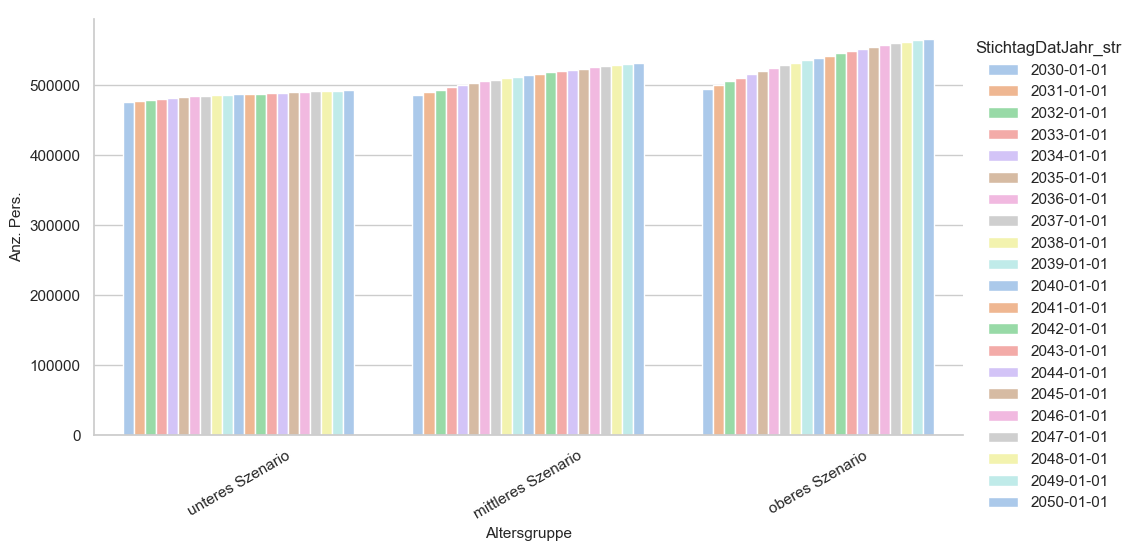

In [45]:
#sns.color_palette("flare", as_cmap=True)
myHist = sns.catplot(x="VersionArtLang"
            , y="sum_WBev"
            , hue="StichtagDatJahr_str" #Muss String sein
            , kind="bar" #boxen, violin, --> wenn die aggregation nicht genau den werten in der grafik entspricht
            , palette="pastel" #, color="green"
            , height=5
            , aspect=2
            , order=None, legend_out=True
            ,data=myAgg1.loc['2030':data_max_date].reset_index()
           )
myHist.set_xticklabels(rotation=30) 
myHist.set_xlabels('Altersgruppe', fontsize=11) # not set_label
myHist.set_ylabels('Anz. Pers.', fontsize=11)


#### Faced Grids

In [46]:
data2betested.columns

Index(['VersionArtSort', 'VersionArtLang', 'BasisSzenarienSort', 'BasisSzenarienLang',
       'AlterV10Sort', 'AlterV10Lang', 'SexSort', 'SexLang', 'HerkunftSort', 'HerkunftLang',
       'QuarSort', 'QuarLang', 'AnzBestWir', 'StichtagDatJahr_str', 'Jahr', 'Jahr_nbr'],
      dtype='object')

In [47]:
myFG = data2betested.loc['2024':data_max_date]\
    .groupby(['StichtagDatJahr', 'VersionArtSort', 'VersionArtLang','QuarLang', 'QuarSort','StichtagDatJahr_str', 'Jahr', 'Jahr_nbr']) \
    .agg(sum_WBev=('AnzBestWir', 'sum')) \
    .sort_values('QuarSort', ascending=True) 
myFG

,,,,,,,,sum_WBev
StichtagDatJahr,VersionArtSort,VersionArtLang,QuarLang,QuarSort,StichtagDatJahr_str,Jahr,Jahr_nbr,
2026-01-01,2,mittleres Szenario,Unbekannt (Kreis 1),10,2026-01-01,2026-01-01,2026,5770
2042-01-01,2,mittleres Szenario,Unbekannt (Kreis 1),10,2042-01-01,2042-01-01,2042,5880
2034-01-01,2,mittleres Szenario,Unbekannt (Kreis 1),10,2034-01-01,2034-01-01,2034,5850
2042-01-01,3,oberes Szenario,Unbekannt (Kreis 1),10,2042-01-01,2042-01-01,2042,5960
2034-01-01,1,unteres Szenario,Unbekannt (Kreis 1),10,2034-01-01,2034-01-01,2034,5790
...,...,...,...,...,...,...,...,...
2032-01-01,1,unteres Szenario,Hirzenbach,123,2032-01-01,2032-01-01,2032,15510
2042-01-01,2,mittleres Szenario,Hirzenbach,123,2042-01-01,2042-01-01,2042,17430
2036-01-01,1,unteres Szenario,Hirzenbach,123,2036-01-01,2036-01-01,2036,15830


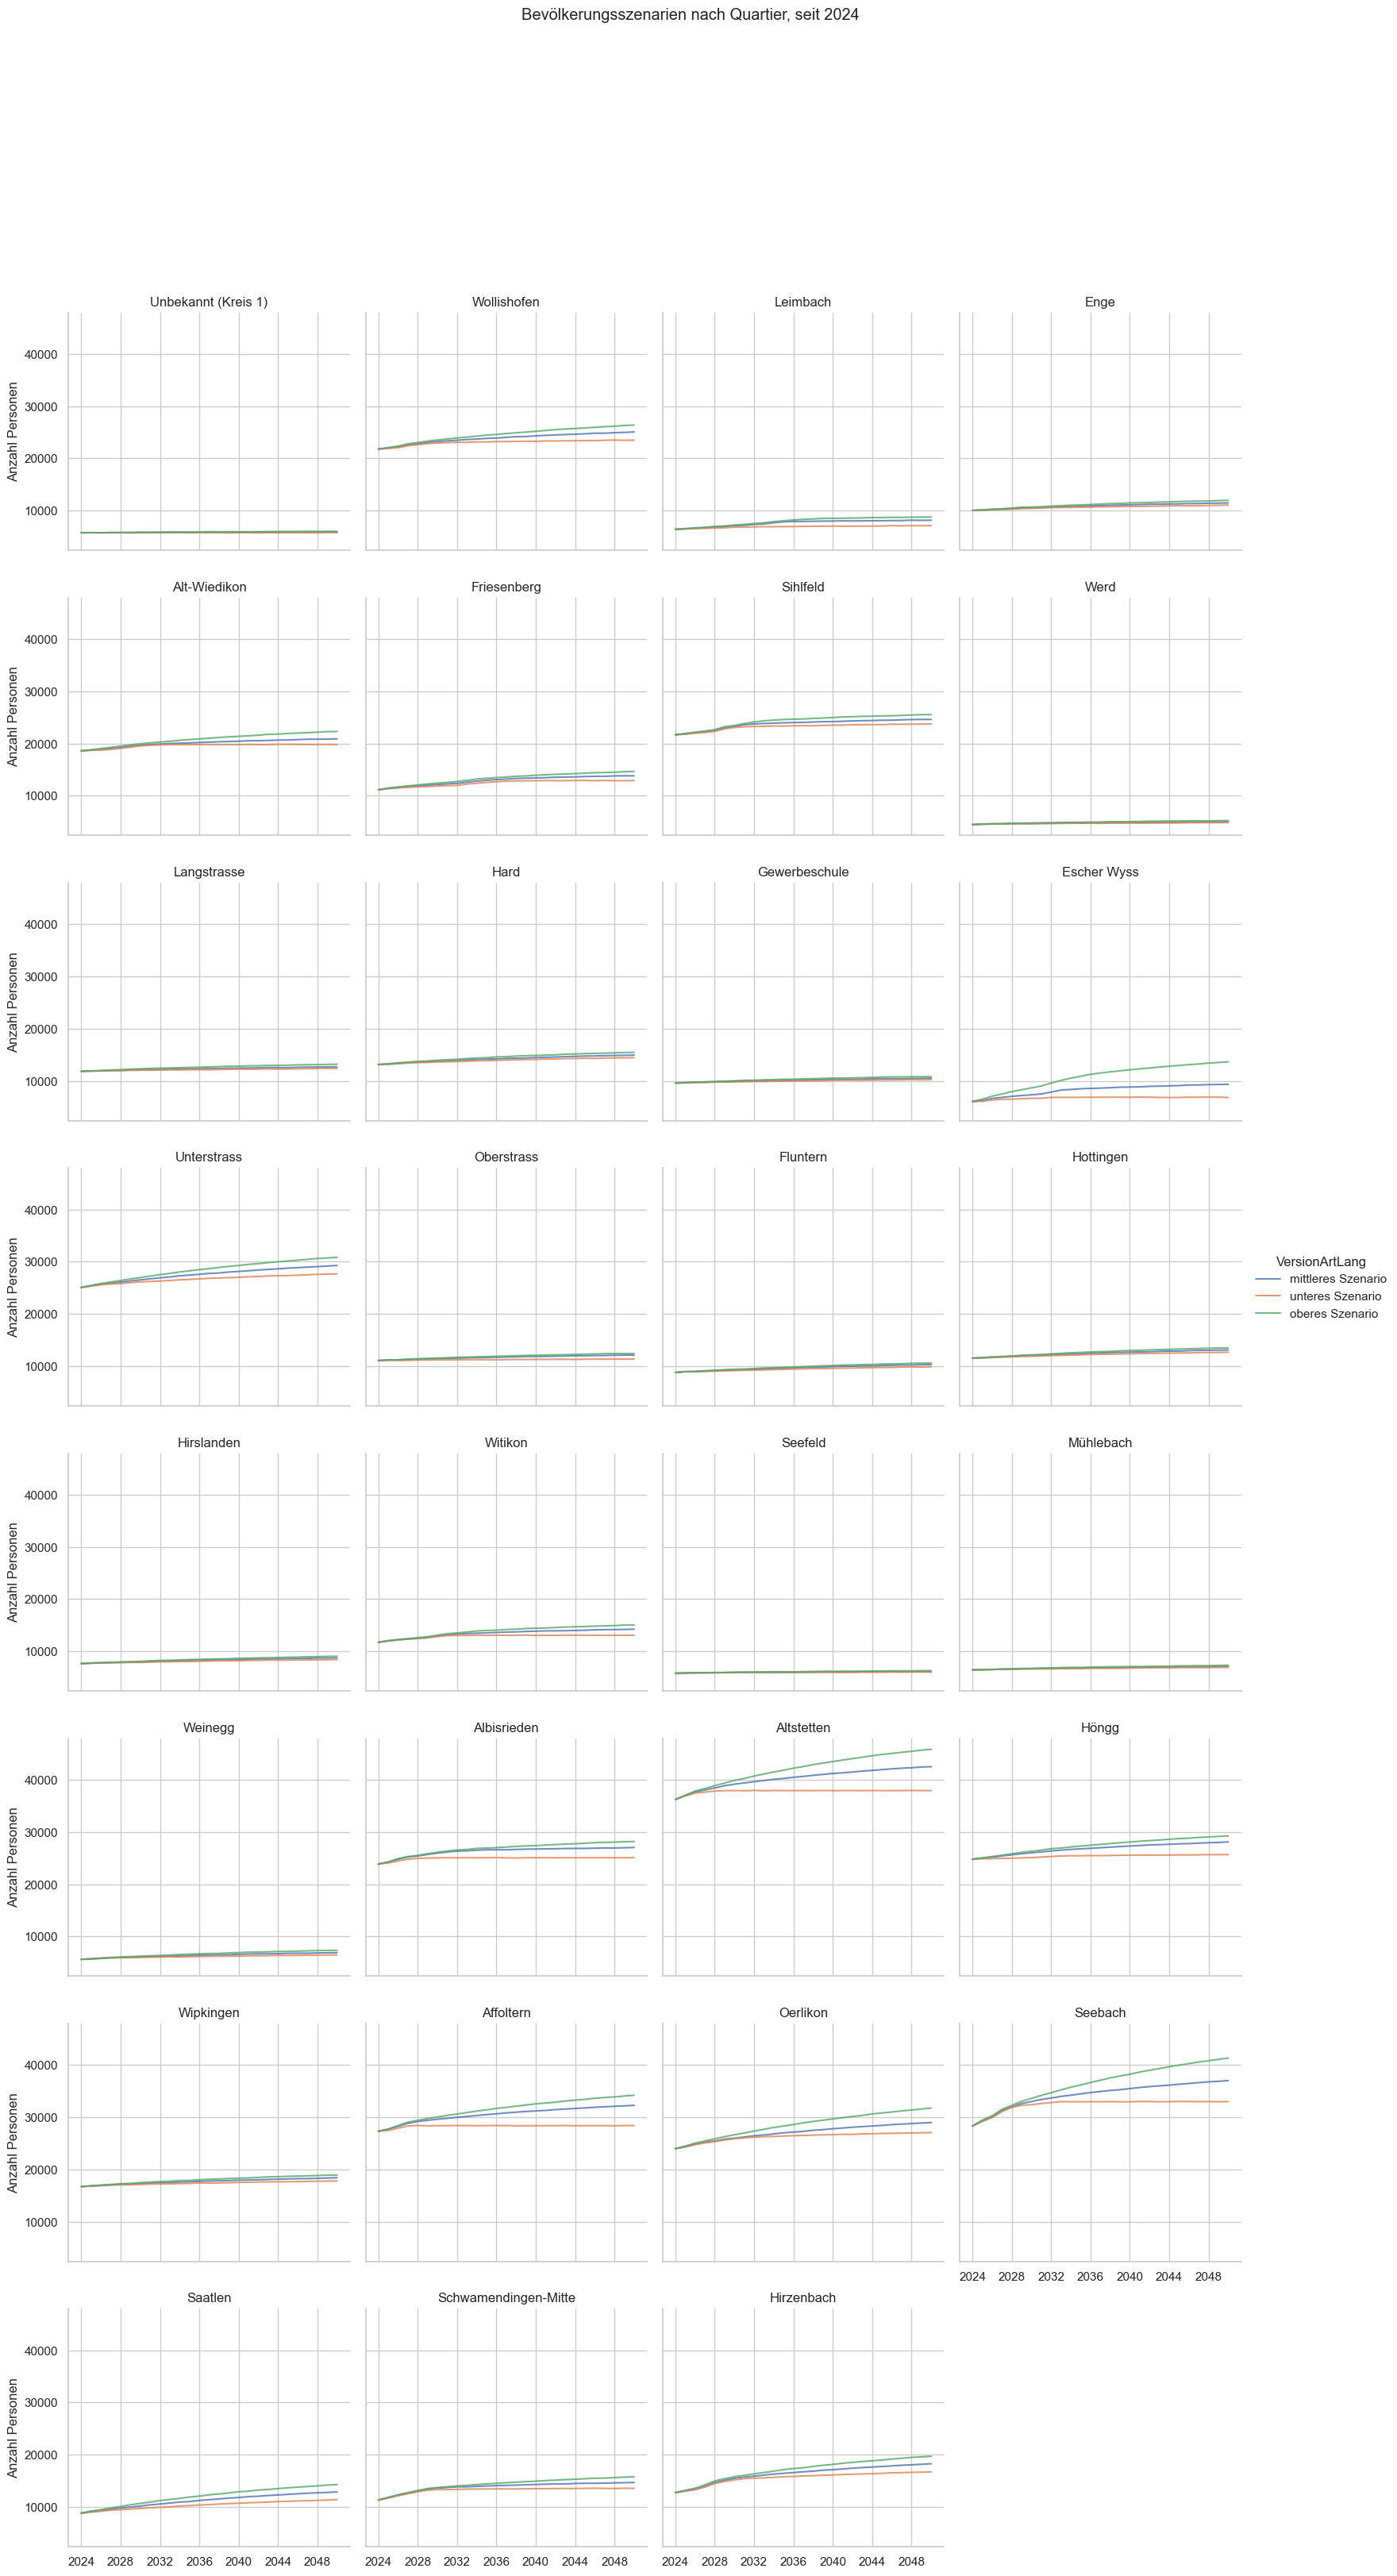

In [48]:
faced_grid1 = mypy_dv.plot_sns_facetgrid(
    data = myFG.reset_index().sort_values('QuarSort', ascending=True)
    ,col = "QuarLang"
    ,hue = "VersionArtLang"
    ,col_wrap = 4
    ,grafiktyp = sns.lineplot
    ,x = "StichtagDatJahr"
    ,y = "sum_WBev"
    ,ylabel= "Anzahl Personen"
    ,warning_status ="ignore"
    ,height = 3
    ,myTitle="Bevölkerungsszenarien nach Quartier, seit 2024"
    #"+str(int(data2betested.index.year.min()))
    
)
faced_grid1

#### Treemaps

**Funktion zum einfärben**

Muss ich noch als Funktion umsetzen 

In [49]:
  qual12br = ["#5D4BFE", "#4AA9FF", "#55FFFF", "#986AD5", "#FC4C99", "#FF919A", "#349894", "#44B14A", "#B7E14E", "#B97624", "#FF7231", "#FFD736"]
  qual12 = ["#3431DE", "#0A8DF6", "#23C3F1", "#7B4FB7", "#DB247D", "#FB737E", "#007C78", "#1F9E31", "#99C32E", "#9A5B01", "#FF720C", "#FBB900"]
  qual12da = ["#0017BF", "#0072D7", "#00A5D2", "#5E359A", "#BA0062", "#DA5563", "#00615D", "#00770F", "#7BA600", "#7B4100", "#DC5500", "#DA9C00"]
  div9val = ["#782600", "#CC4309", "#FF720C", "#FFBC88", "#E4E0DF", "#AECBFF", "#6B8EFF", "#3B51FF", "#2F2ABB",]
  div9ntr = ["#A30059", "#DB247D", "#FF579E", "#FFA8D0", "#E4E0DF", "#A8DBB1", "#55BC5D", "#1F9E31", "#10652A",]

In [50]:
# Extrahiere die Top-Fahrzeugmarken
quartiere = data2betested['QuarLang'].unique().tolist()
# Verfügbare Farben
verfügbare_farben_zuericolors = div9ntr+qual12da+qual12br+qual12

# Erstelle das Farben-Dictionary
farben_dict_zc = {'(?)':'lightgrey'}
for index, x in enumerate(quartiere):
    farben_dict_zc[x] = verfügbare_farben_zuericolors[index % len(verfügbare_farben_zuericolors)]

# Das resultierende Farben-Dictionary
print(farben_dict_zc)
#print(verfügbare_farben_zuericolors)

{'(?)': 'lightgrey', 'Unbekannt (Kreis 1)': '#A30059', 'Hottingen': '#DB247D', 'Fluntern': '#FF579E', 'Oberstrass': '#FFA8D0', 'Unterstrass': '#E4E0DF', 'Escher Wyss': '#A8DBB1', 'Seefeld': '#55BC5D', 'Alt-Wiedikon': '#1F9E31', 'Oerlikon': '#10652A', 'Affoltern': '#0017BF', 'Wipkingen': '#0072D7', 'Höngg': '#00A5D2', 'Altstetten': '#5E359A', 'Albisrieden': '#BA0062', 'Weinegg': '#DA5563', 'Mühlebach': '#00615D', 'Witikon': '#00770F', 'Hirslanden': '#7BA600', 'Seebach': '#7B4100', 'Saatlen': '#DC5500', 'Hard': '#DA9C00', 'Enge': '#5D4BFE', 'Leimbach': '#4AA9FF', 'Wollishofen': '#55FFFF', 'Werd': '#986AD5', 'Hirzenbach': '#FC4C99', 'Schwamendingen-Mitte': '#FF919A', 'Friesenberg': '#349894', 'Langstrasse': '#44B14A', 'Gewerbeschule': '#B7E14E', 'Sihlfeld': '#B97624'}


##### Bevszen nach Stadtquartier

In [51]:
data2betested.columns

Index(['VersionArtSort', 'VersionArtLang', 'BasisSzenarienSort', 'BasisSzenarienLang',
       'AlterV10Sort', 'AlterV10Lang', 'SexSort', 'SexLang', 'HerkunftSort', 'HerkunftLang',
       'QuarSort', 'QuarLang', 'AnzBestWir', 'StichtagDatJahr_str', 'Jahr', 'Jahr_nbr'],
      dtype='object')

In [52]:
myTM = data2betested.loc[data_max_date].reset_index() \
    .groupby(['StichtagDatJahr', 'QuarSort', 'QuarLang', 'VersionArtSort', 'VersionArtLang']) \
    .agg(AnzBestWir=('AnzBestWir', 'sum')) \
    .sort_values('AnzBestWir', ascending=False) 

myTM.reset_index().head(2)

,StichtagDatJahr,QuarSort,QuarLang,VersionArtSort,VersionArtLang,AnzBestWir
0,2050-01-01,92,Altstetten,3,oberes Szenario,45880
1,2050-01-01,92,Altstetten,2,mittleres Szenario,42550


In [53]:
treeMap1 = mypy_dv.plot_px_treemap(
    data=myTM.reset_index()
    ,levels=['QuarLang','VersionArtLang']
    ,values="AnzBestWir"
    ,color="QuarLang"
    #, color_continuous_scale='Blues'
    ,color_discrete_map= farben_dict_zc
    ,height=400
    ,width=1100               
    #,margin_val_bottom=25
    ,myHeaderTitle="Szenarien nach Statistischem Quartier, "+data_max_date
)
treeMap1

path: [<plotly.express._special_inputs.Constant object at 0x0000021782011C50>, 'QuarLang', 'VersionArtLang']
Typ von path: <class 'list'>


## ---------------------- hier Plausi beendet

**Sharepoint als gecheckt markieren!**

Record auf Sharepoint: **[Link](https://kollaboration.intranet.stzh.ch/orga/ssz-produkte/Lists/SASA_Outputs/DispForm.aspx?ID=40)**

---------------------------------------------------------------------------